In [1]:
# Import libraries required for data manipulation (pandas, numpy),
# visualization (matplotlib, seaborn)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load the dataset into a pandas DataFrame for further analysis
url="https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/diabetes.csv"
df= pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Explore the dataset structure, dimensions, and basic statistical summary
df.shape

(768, 9)

In [5]:
# Explore the dataset structure, dimensions, and basic statistical summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Explore the dataset structure, dimensions, and basic statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Explore the dataset structure, dimensions, and basic statistical summary
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
# Identify the number of zero values in each column to detect potential invalid or missing data
(df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']]==0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [10]:
# Replace invalid zero values with NaN to properly represent missing data
cols= ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols]= df[cols].replace(0, np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
# Fill missing values (NaN) in each column using the median to reduce the effect of outliers
for col in cols:
  df[col].fillna(df[col].median(), inplace=True)
df.isnull().sum()

/tmp/ipykernel_384/1449691083.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [15]:
# Cap extreme outliers by limiting values above the 99th percentile (quantile 0.99)
upper= df['Insulin'].quantile(0.99)
df['Insulin']= np.where(df['Insulin']> upper, upper, df['Insulin'])
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,139.407729,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,79.046433,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,513.267000,67.100000,2.420000,81.000000,1.000000


In [16]:
# Check the distribution of the target variable (Outcome) to understand class balance
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


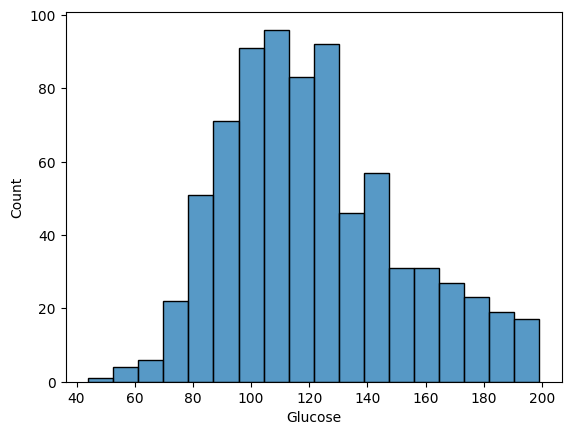

In [17]:
# Plot a histogram to visualize the distribution of glucose values
sns.histplot(df["Glucose"])
plt.show()

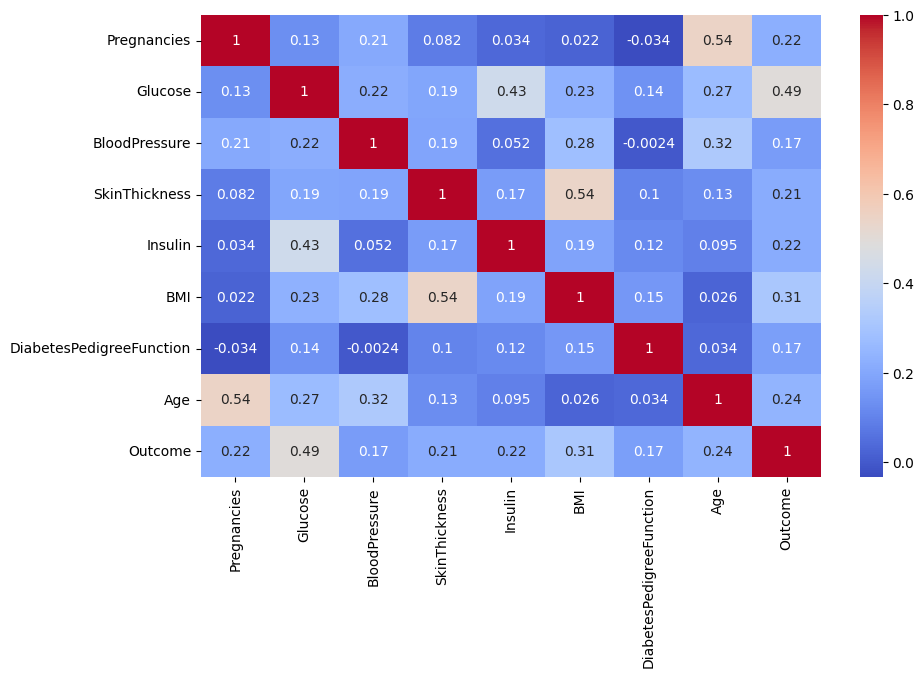

In [18]:
# Visualize the correlation between features using a heatmap to identify relationships with the target variable
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

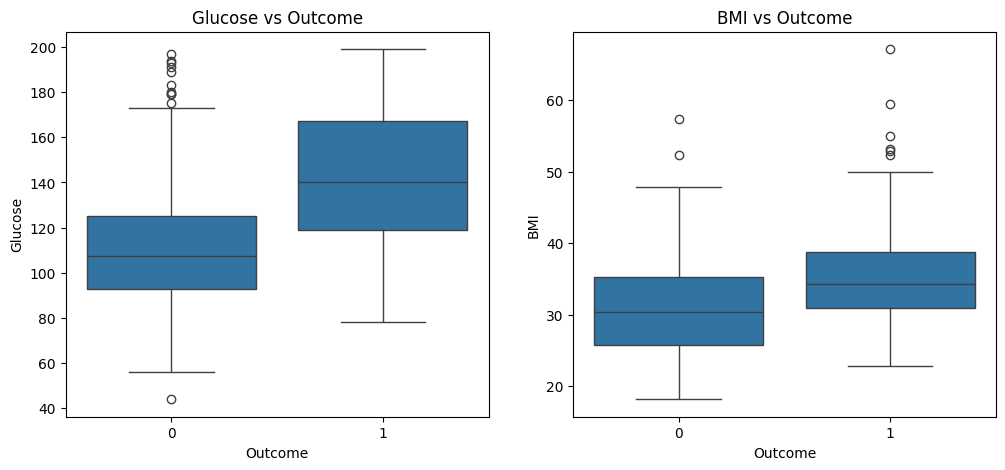

In [19]:
# Compare the distributions of Glucose and BMI across diabetes outcomes using boxplots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose vs Outcome")

plt.subplot(1,2,2)
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI vs Outcome")

plt.show()

In [20]:
# Separate features (X) and target variable (y) by dropping the Outcome column from the dataset
X= df.drop("Outcome", axis=1)
y= df["Outcome"]

In [21]:
# Split the dataset into training and testing sets to evaluate the model performance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [24]:
# Standardize feature values using StandardScaler to ensure all features contribute equally to the KNN model
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [25]:
# Import the K-Nearest Neighbors (KNN) classifier for building the machine learning model
from sklearn.neighbors import KNeighborsClassifier

model= KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
# Predicting
y_pred= model.predict(X_test)

In [27]:
# Evaluate the model's performance using accuracy score
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6753246753246753

<Axes: >

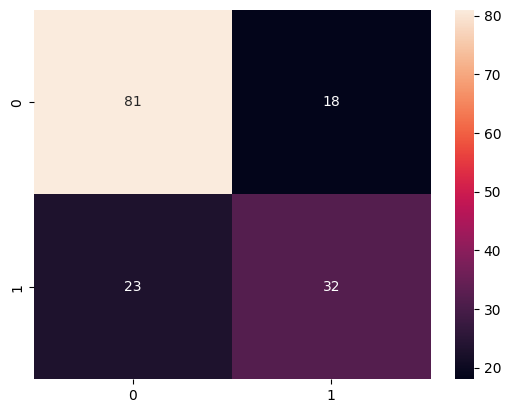

In [38]:
# Compute and visualize the confusion matrix to evaluate how well the model classifies each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

In [29]:
# Generate a classification report to evaluate precision, recall, and F1-score for each class
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        99
           1       0.54      0.62      0.58        55

    accuracy                           0.68       154
   macro avg       0.65      0.66      0.66       154
weighted avg       0.69      0.68      0.68       154



In [30]:
# Determine the optimal number of neighbors (K) by evaluating model accuracy across different K values
scores = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

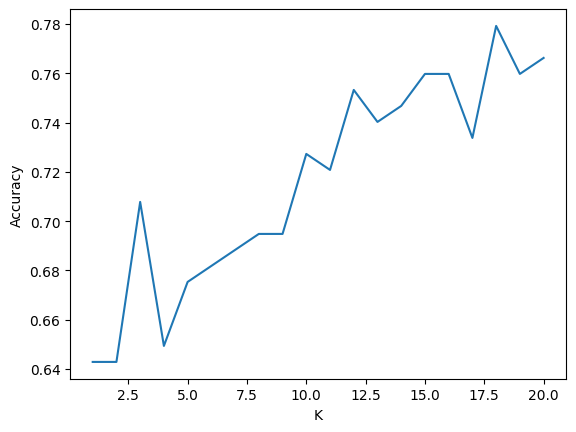

In [31]:
# Plot the accuracy scores for different K values to visualize and identify the optimal number of neighbors
plt.plot(range(1,21), scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [39]:
# Retrain the KNN model using the optimal number of neighbors (K) obtained from hyperparameter tuning
model = KNeighborsClassifier(n_neighbors=17)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.7337662337662337

<Axes: >

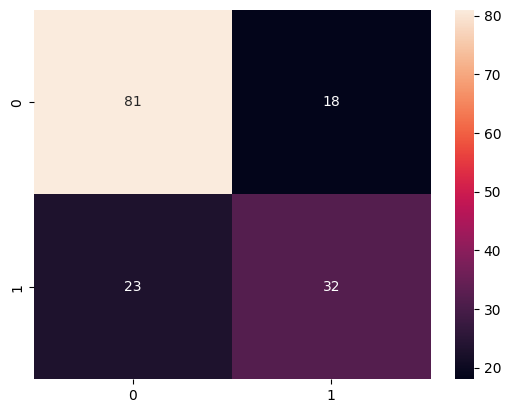

In [36]:
# Recompute the confusion matrix to evaluate the performance of the optimized KNN model
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

In [37]:
# Generate the classification report again to evaluate the performance of the optimized KNN model
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80        99
           1       0.64      0.58      0.61        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



The KNN model was trained to predict diabetes based on medical indicators.

After hyperparameter tuning, the optimal number of neighbors was found to be K=17.

The final model achieved approximately 73% accuracy on the test dataset.

Glucose and BMI appeared to be strong indicators of diabetes risk.

In [40]:
import joblib
joblib.dump(model, "diabetes_knn_model.pkl")


['diabetes_knn_model.pkl']

In [41]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']